# PANNs CNN14  -  Audio Event Evaluation

Evaluates PANNs CNN14 on 9 surveillance audio clips extracted from scene videos.
Compares predictions against ground-truth labels and computes performance metrics.

**Model**: PANNs CNN14 (panns_inference.AudioTagging)
**VRAM**: ~50 MB


In [1]:
import json, os, re, sys, warnings
from pathlib import Path
from typing import List, Tuple

import numpy as np
import soundfile as sf
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

warnings.filterwarnings("ignore")
%matplotlib inline

# --- auto-detect project root ---
_root = Path.cwd()
for _p in [_root] + list(_root.parents):
    if (_p / ".gitignore").exists():
        PROJECT_ROOT = _p; break
else:
    PROJECT_ROOT = _root
del _root, _p
# --------------------------------


In [2]:
import re

AUDIO_DIR = PROJECT_ROOT / "data/audio/eval"
SAMPLE_RATE = 16000
PANNS_SR = 32000

GROUND_TRUTH = {
    "scene1_scream_2.625-4.792.wav": "scream",
    "scene2_scream_2.667-5.083.wav": "scream",
    "scene3_scream_2.500-6.250.wav": "scream",
    "scene4_shout_0.000-1.500.wav": "shout",
    "scene4_impact_1.500-1.667.wav": "impact",
    "scene5_shout_0.000-1.833.wav": "shout",
    "scene5_impact_1.833-5.125.wav": "impact",
    "scene6_shout_0.000-2.167.wav": "shout",
    "scene6_impact_2.500-3.000.wav": "impact",
    "scene7_gunshot_or_explosion_4.000-4.375.wav": "gunshot_or_explosion",
    "scene7_gunshot_or_explosion_4.833-6.667.wav": "gunshot_or_explosion",
    "scene8_gunshot_or_explosion_2.500-3.208.wav": "gunshot_or_explosion",
    "scene9_gunshot_or_explosion_4.750-5.750.wav": "gunshot_or_explosion",
    "scene10_gunshot_or_explosion_0.583-4.167.wav": "gunshot_or_explosion",
    "scene11_gunshot_or_explosion_1.542-4.167.wav": "gunshot_or_explosion",
    "scene12_engine_3.875-5.500.wav": "engine",
    "scene12_tire_squeal_5.500-8.667.wav": "tire_squeal",
    "scene13_engine_3.958-7.875.wav": "engine",
    "scene13_tire_squeal_7.875-9.083.wav": "tire_squeal",
    "scene14_engine_3.667-7.042.wav": "engine",
    "scene14_tire_squeal_7.042-9.167.wav": "tire_squeal",
    "scene15_horn_0.792-3.042.wav": "horn",
    "scene15_impact_3.042-3.292.wav": "impact",
    "scene15_glass_breaking_3.292-4.542.wav": "glass_breaking",
    "scene16_skidding_1.292-2.208.wav": "skidding",
    "scene16_impact_2.208-2.458.wav": "impact",
    "scene16_glass_breaking_2.625-5.417.wav": "glass_breaking",
    "scene17_horn_1.250-3.083.wav": "horn",
    "scene17_skidding_2.208-3.083.wav": "skidding",
    "scene17_glass_breaking_3.083-4.583.wav": "glass_breaking"
}

CLASSES = sorted(set(GROUND_TRUTH.values()))
_GT_LABELS = sorted(set(GROUND_TRUTH.values()), key=len, reverse=True)

_RE_KEEP = re.compile(r"[^a-zA-Z0-9_ ]+")

def _stem(word: str) -> str:
    w = word.lower().strip("_.,;:!?")
    for suf in ["ing", "ed", "ly", "s", "es", "ies", "ness", "tion"]:
        if w.endswith(suf) and len(w) > len(suf) + 2:
            return w[:-len(suf)]
    return w

_GT_KEYWORDS = {
    "scream":          {"scream"},
    "shout":           {"shout", "yell"},
    "impact":          {"impact", "thump", "thud", "bang", "slam", "smash", "crash", "punch", "hit"},
    "gunshot_or_explosion": {"gunshot", "gunfire", "artillery_fire", "artillery", "explosion", "explosive", "firework", "boom"},
    "engine":          {"engine", "vehicle", "car"},
    "tire_squeal":     {"tire", "tyre", "tire_squeal", "screech", "squeal"},
    "skidding":        {"skidding", "skid"},
    "glass_breaking":  {"glass", "glass_breaking", "shatter", "shattering"},
    "horn":        {"horn", "honk", "honking"},
}

_SYNONYM_LOOKUP: dict[str, str] = {}
for gt, kws in _GT_KEYWORDS.items():
    for kw in kws:
        _SYNONYM_LOOKUP[kw] = gt
        _SYNONYM_LOOKUP[_stem(kw)] = gt

TIRE_SQUEAL_KWS = _GT_KEYWORDS["tire_squeal"]
HORN_KWS = _GT_KEYWORDS["horn"]

def _resolve_label(text: str) -> str | None:
    clean = _RE_KEEP.sub(" ", text or "").lower()
    clean = " ".join(clean.split())
    if not clean:
        return None
    tokens = [t.strip("_.,;:!?'\"") for t in re.split(r"[_ ,;:\-]+", clean)]
    tokens = [t for t in tokens if len(t) >= 2]
    if not tokens:
        return None
    # Priority: if any token is a tire_squeal keyword, resolve to tire_squeal
    for token in tokens:
        if token in TIRE_SQUEAL_KWS or _stem(token) in TIRE_SQUEAL_KWS:
            return "tire_squeal"
    # Priority: if any token is a horn keyword, resolve to horn
    for token in tokens:
        if token in HORN_KWS or _stem(token) in HORN_KWS:
            return "horn"
    fallback = tokens[0]
    for token in tokens:
        if token in _SYNONYM_LOOKUP:
            return _SYNONYM_LOOKUP[token]
        s = _stem(token)
        if s in _SYNONYM_LOOKUP:
            return _SYNONYM_LOOKUP[s]
        if token in _GT_LABELS:
            return token
    return fallback

def resample(audio: np.ndarray, sr_in: int, sr_out: int) -> np.ndarray:
    import scipy.signal
    if sr_in == sr_out:
        return audio
    n_out = int(round(len(audio) * sr_out / sr_in))
    return scipy.signal.resample(audio.astype(np.float32), n_out).astype(np.float32)


In [3]:
print("Loading PANNs CNN14...", flush=True)
from panns_inference import AudioTagging
_panns = AudioTagging(device="cuda" if torch.cuda.is_available() else "cpu")
_panns.model.eval()

def _panns_infer(audio_np):
    audio_t = torch.tensor(audio_np, dtype=torch.float32)
    if audio_t.dim() == 1:
        audio_t = audio_t.unsqueeze(0)
    if _panns.device != "cpu":
        audio_t = audio_t.to(_panns.device)
    with torch.no_grad():
        out = _panns.model(audio_t, None)
    return out["clipwise_output"][0].detach().cpu().tolist(), out["embedding"][0].detach().cpu().tolist()

print(f"PANNs loaded on {_panns.device}")


Loading PANNs CNN14...


Checkpoint path: /home/ghiffaryr/panns_data/Cnn14_mAP=0.431.pth


GPU number: 1
PANNs loaded on cuda


In [4]:
def predict_panns(audio_16k: np.ndarray) -> List[Tuple[str, float]]:
    audio_32k = resample(audio_16k, SAMPLE_RATE, PANNS_SR)
    if audio_32k.size < PANNS_SR // 2:
        audio_32k = np.concatenate([audio_32k, np.zeros(PANNS_SR // 2 - audio_32k.size, dtype=np.float32)])
    probs, _ = _panns_infer(audio_32k[None, :])
    if isinstance(probs, list) and probs and isinstance(probs[0], list):
        probs = probs[0]
    best_label, best_prob = None, 0.0
    for l, p in zip(_panns.labels, probs):
        if p > best_prob:
            best_label, best_prob = l, p
    pred = best_label.lower() if best_label else "none"
    print(f"  Raw: {best_label} ({best_prob:.3f})")
    return pred, best_prob

results = []

wav_files = sorted(AUDIO_DIR.glob("*.wav"))
print(f"Found {len(wav_files)} eval clips\n")

import time
start_time = time.time()

for wf in wav_files:
    true_label = GROUND_TRUTH[wf.name]
    audio_16k, sr = sf.read(str(wf), dtype="float32")
    if audio_16k.ndim > 1:
        audio_16k = audio_16k.mean(axis=-1)

    predicted_label, top_conf = predict_panns(audio_16k)
    predicted_label = _resolve_label(predicted_label) or "none"
    top_conf = top_conf or 0.0
    correct = predicted_label == true_label

    results.append({
        "file": wf.name,
        "true": true_label,
        "predicted": predicted_label,
        "confidence": top_conf,
        "correct": correct,
    })

    mark = "[OK]" if correct else "[NO]"
    print(f"{mark:5s} {wf.name:45s} true={true_label:12s} pred={predicted_label} ({top_conf:.3f})")

elapsed = time.time() - start_time

correct = sum(1 for r in results if r["correct"])
total = len(results)
print(f"\nAccuracy: {correct}/{total} ({100*correct//total}%)")
print(f"Total inference time: {elapsed:.1f}s ({elapsed/total:.2f}s per clip)")


Found 30 eval clips



  Raw: Boom (0.382)
[OK]  scene10_gunshot_or_explosion_0.583-4.167.wav  true=gunshot_or_explosion pred=gunshot_or_explosion (0.382)
  Raw: Explosion (0.487)
[OK]  scene11_gunshot_or_explosion_1.542-4.167.wav  true=gunshot_or_explosion pred=gunshot_or_explosion (0.487)
  Raw: Vehicle (0.912)
[OK]  scene12_engine_3.875-5.500.wav                true=engine       pred=engine (0.912)
  Raw: Vehicle (0.694)
[NO]  scene12_tire_squeal_5.500-8.667.wav           true=tire_squeal  pred=engine (0.694)
  Raw: Vehicle (0.776)
[OK]  scene13_engine_3.958-7.875.wav                true=engine       pred=engine (0.776)
  Raw: Vehicle (0.752)
[NO]  scene13_tire_squeal_7.875-9.083.wav           true=tire_squeal  pred=engine (0.752)
  Raw: Vehicle (0.923)
[OK]  scene14_engine_3.667-7.042.wav                true=engine       pred=engine (0.923)
  Raw: Vehicle (0.744)
[NO]  scene14_tire_squeal_7.042-9.167.wav           true=tire_squeal  pred=engine (0.744)
  Raw: Breaking (0.094)
[NO]  scene15_glass_breaking_

  Raw: Vehicle (0.777)
[NO]  scene15_horn_0.792-3.042.wav                  true=horn         pred=engine (0.777)
  Raw: Music (0.225)
[NO]  scene15_impact_3.042-3.292.wav                true=impact       pred=music (0.225)
  Raw: Shatter (0.591)
[OK]  scene16_glass_breaking_2.625-5.417.wav        true=glass_breaking pred=glass_breaking (0.591)
  Raw: Music (0.135)
[NO]  scene16_impact_2.208-2.458.wav                true=impact       pred=music (0.135)
  Raw: Skidding (0.880)
[OK]  scene16_skidding_1.292-2.208.wav              true=skidding     pred=skidding (0.880)
  Raw: Explosion (0.148)
[NO]  scene17_glass_breaking_3.083-4.583.wav        true=glass_breaking pred=gunshot_or_explosion (0.148)
  Raw: Vehicle (0.755)
[NO]  scene17_horn_1.250-3.083.wav                  true=horn         pred=engine (0.755)
  Raw: Vehicle (0.678)
[NO]  scene17_skidding_2.208-3.083.wav              true=skidding     pred=engine (0.678)
  Raw: Crowd (0.481)
[NO]  scene1_scream_2.625-4.792.wav               

  Raw: Screaming (0.804)
[OK]  scene3_scream_2.500-6.250.wav                 true=scream       pred=scream (0.804)
  Raw: Music (0.121)
[NO]  scene4_impact_1.500-1.667.wav                 true=impact       pred=music (0.121)
  Raw: Speech (0.866)
[NO]  scene4_shout_0.000-1.500.wav                  true=shout        pred=speech (0.866)
  Raw: Speech (0.675)
[NO]  scene5_impact_1.833-5.125.wav                 true=impact       pred=speech (0.675)
  Raw: Speech (0.790)
[NO]  scene5_shout_0.000-1.833.wav                  true=shout        pred=speech (0.790)
  Raw: Speech (0.163)
[NO]  scene6_impact_2.500-3.000.wav                 true=impact       pred=speech (0.163)
  Raw: Speech (0.727)
[NO]  scene6_shout_0.000-2.167.wav                  true=shout        pred=speech (0.727)
  Raw: Artillery fire (0.301)
[OK]  scene7_gunshot_or_explosion_4.000-4.375.wav   true=gunshot_or_explosion pred=gunshot_or_explosion (0.301)
  Raw: Explosion (0.309)
[OK]  scene7_gunshot_or_explosion_4.833-6.667.wa

In [5]:
print("\n=== Classification Report ===\n")

y_true = [r["true"] for r in results]
y_pred = [r["predicted"] if r["predicted"] in CLASSES else "other" for r in results]

all_labels = sorted(set(y_true + [l for l in y_pred if l != "other"]))
if "other" in [l for l in y_pred]:
    all_labels.append("other")

print(classification_report(y_true, y_pred, labels=all_labels, zero_division=0))

# Per-class metrics
print("\n--- Per-Class Metrics ---")
classes_in_data = sorted(set(y_true))
for cls in classes_in_data:
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == cls and p == cls)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t != cls and p == cls)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == cls and p != cls)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    support = tp + fn
    print(f"  {cls:12s}  prec={precision:.3f}  recall={recall:.3f}  f1={f1:.3f}  support={support}")



=== Classification Report ===

                      precision    recall  f1-score   support

              engine       0.33      1.00      0.50         3
      glass_breaking       1.00      0.33      0.50         3
gunshot_or_explosion       0.86      1.00      0.92         6
                horn       0.00      0.00      0.00         2
              impact       0.00      0.00      0.00         5
              scream       1.00      0.67      0.80         3
               shout       0.00      0.00      0.00         3
            skidding       1.00      0.50      0.67         2
         tire_squeal       0.00      0.00      0.00         3
               other       0.00      0.00      0.00         0

            accuracy                           0.43        30
           macro avg       0.42      0.35      0.34        30
        weighted avg       0.47      0.43      0.41        30


--- Per-Class Metrics ---
  engine        prec=0.333  recall=1.000  f1=0.500  support=3
  glass_

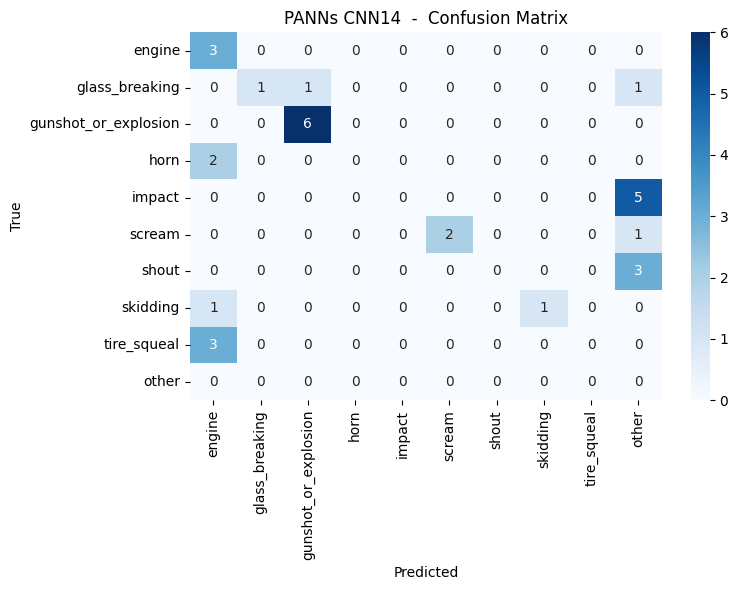

In [6]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=all_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=all_labels, yticklabels=all_labels)
plt.title("PANNs CNN14  -  Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments/notebooks/panns_confusion_matrix.png", dpi=150)
plt.show()


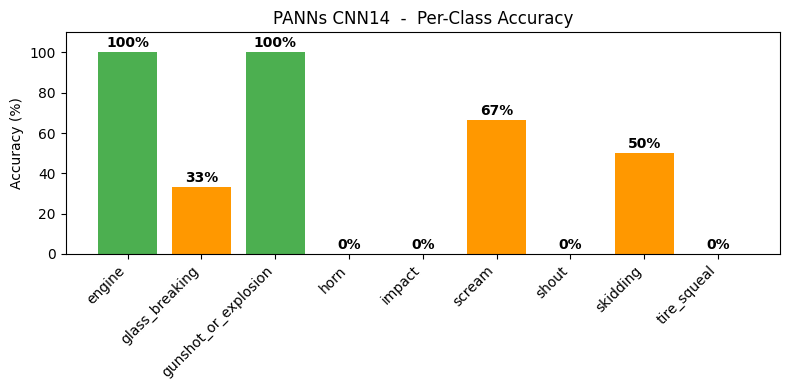

In [7]:
# Accuracy per class
classes_in_data = sorted(set(y_true))
correct_by_class = {}
total_by_class = {}
for cls in classes_in_data:
    correct_by_class[cls] = sum(1 for t, p in zip(y_true, y_pred) if t == cls and p == cls)
    total_by_class[cls] = sum(1 for t in y_true if t == cls)

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(classes_in_data))
accs = [correct_by_class[c] / total_by_class[c] * 100 for c in classes_in_data]
bars = ax.bar(x, accs, color=["#4CAF50" if a == 100 else "#FF9800" for a in accs])
ax.set_xticks(x)
ax.set_xticklabels(classes_in_data, rotation=45, ha="right")
ax.set_ylabel("Accuracy (%)")
ax.set_title("PANNs CNN14  -  Per-Class Accuracy")
ax.set_ylim(0, 110)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{acc:.0f}%",
            ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments/notebooks/panns_per_class_accuracy.png", dpi=150)
plt.show()


In [8]:
# Metrics Summary
from sklearn.metrics import precision_recall_fscore_support

mac_p, mac_r, mac_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
wgt_p, wgt_r, wgt_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
print("=== Metrics Summary ===")
print(f"  Macro     P={mac_p:.3f}  R={mac_r:.3f}  F1={mac_f1:.3f}")
print(f"  Weighted  P={wgt_p:.3f}  R={wgt_r:.3f}  F1={wgt_f1:.3f}")
print(f"  Accuracy: {correct}/{total} ({100*correct//total}%)")


=== Metrics Summary ===
  Macro     P=0.419  R=0.350  F1=0.339
  Weighted  P=0.471  R=0.433  F1=0.409
  Accuracy: 13/30 (43%)


In [9]:
# Detailed results table
print(f"{'File':45s} {'True':12s} {'Predicted':12s} {'Conf':6s} {'Correct':8s}")
print("-" * 85)
for r in results:
    mark = "[OK]" if r["correct"] else "[NO]"
    print(f"{r['file']:45s} {r['true']:12s} {r['predicted']:12s} {r['confidence']:.3f}  {mark:8s}")
print(f"\nOverall: {correct}/{total} ({100*correct//total}%)")


File                                          True         Predicted    Conf   Correct 
-------------------------------------------------------------------------------------
scene10_gunshot_or_explosion_0.583-4.167.wav  gunshot_or_explosion gunshot_or_explosion 0.382  [OK]    
scene11_gunshot_or_explosion_1.542-4.167.wav  gunshot_or_explosion gunshot_or_explosion 0.487  [OK]    
scene12_engine_3.875-5.500.wav                engine       engine       0.912  [OK]    
scene12_tire_squeal_5.500-8.667.wav           tire_squeal  engine       0.694  [NO]    
scene13_engine_3.958-7.875.wav                engine       engine       0.776  [OK]    
scene13_tire_squeal_7.875-9.083.wav           tire_squeal  engine       0.752  [NO]    
scene14_engine_3.667-7.042.wav                engine       engine       0.923  [OK]    
scene14_tire_squeal_7.042-9.167.wav           tire_squeal  engine       0.744  [NO]    
scene15_glass_breaking_3.292-4.542.wav        glass_breaking breaking     0.094  [NO]    
